# Native GLO-90 transfer in exposed terrain windows

**Numerical question.** How does the separately processed native Copernicus DEM GLO-90 product change the frozen equivalent steep-area functional relative to GLO-30 `p00` and its strict 3×3 aggregate? The seven windows are already exposed and have no geographic inclusion probabilities. This is source-product development with no pass label, physical susceptibility claim, global estimate, or climate attribution.

In [1]:
from pathlib import Path; import hashlib, json, matplotlib.pyplot as plt, numpy as np, pandas as pd
root = Path('..'); out = root/'data/native_glo90_transfer'
paths = {name:out/name for name in ['raw_source_manifest.json','equivalent_area_long.csv','comparisons.csv']}; expected = {'raw_source_manifest.json':'dba58bae4a36600d55adc6393f891cc0fd95a9baa577e3cb3bfc4ff64233d8a5','equivalent_area_long.csv':'663eff9da6e5972c4625be6505e9c71ca58b6e16ce2783b21455c3a64d64f232','comparisons.csv':'387798fe4b219fb1c6af399fef663c960c6ef3351eb2309c6bfef19a38ed974b'}
assert all(hashlib.sha256(path.read_bytes()).hexdigest() == expected[name] for name,path in paths.items())
raw = json.loads(paths['raw_source_manifest.json'].read_text()); assert raw['responses'] == 63 and raw['http_status_counts'] == {'200':60,'404':3} and len(raw['files']) == 64
long = pd.read_csv(paths['equivalent_area_long.csv'], dtype={'region':str}); comparisons = pd.read_csv(paths['comparisons.csv'], dtype={'region':str})
assert (len(long),len(comparisons)) == (56,14) and long.groupby(['region','phase']).size().eq(2).all()
assert long.support_status.eq('complete').all() and comparisons.native_support_status.eq('complete').all() and comparisons.interpretation.eq('exposed_window_native_source_development_no_pass_label').all()
refs = comparisons[['region','stratum','reference_glo30_p00_m2']]; phase = long.merge(refs,on=['region','stratum'])
phase['departure_pct'] = 100*abs(phase.equivalent_steep_area_m2-phase.reference_glo30_p00_m2)/phase.reference_glo30_p00_m2
ranges = phase.groupby(['region','stratum']).departure_pct.agg(['min','max']).rename(columns={'min':'phase_min_pct','max':'phase_max_pct'}).reset_index()
table = comparisons.merge(ranges,on=['region','stratum']); table['aggregated_pct'] = 100*table.aggregated_glo30_departure; table['native_pct'] = 100*table.native_glo90_departure
short = {'glacier_proximity':'G','permafrost':'P'}; table['label'] = table.region+'  '+table.region_name+' — '+table.stratum.map(short)
assert (table.native_pct > table.aggregated_pct).all()
summary = pd.DataFrame({'metric':['Aggregated departure range (%)','Native n00 departure range (%)','Median aggregated/native departure (%)','Maximum native phase CV (%)','Minimum primary complete support (%)'],'value':[f'{table.aggregated_pct.min():.2f}–{table.aggregated_pct.max():.2f}',f'{table.native_pct.min():.2f}–{table.native_pct.max():.2f}',f'{table.aggregated_pct.median():.2f} / {table.native_pct.median():.2f}',f'{100*table.native_phase_cv.max():.2f}',f'{100*table.primary_complete_support_fraction.min():.3f}']})
summary

,metric,value
0,Aggregated departure range (%),1.81–13.43
1,Native n00 departure range (%),3.45–24.81
2,Median aggregated/native departure (%),3.44 / 6.65
3,Maximum native phase CV (%),4.17
4,Minimum primary complete support (%),99.681


All 14 window–stratum comparisons retain complete mask-specific support even though three halo-object requests returned 404. The 404s are not treated as irrelevant: finite and complete-center fractions expose their raster effect, while the registered mask-support rule determines whether an area is resolved.

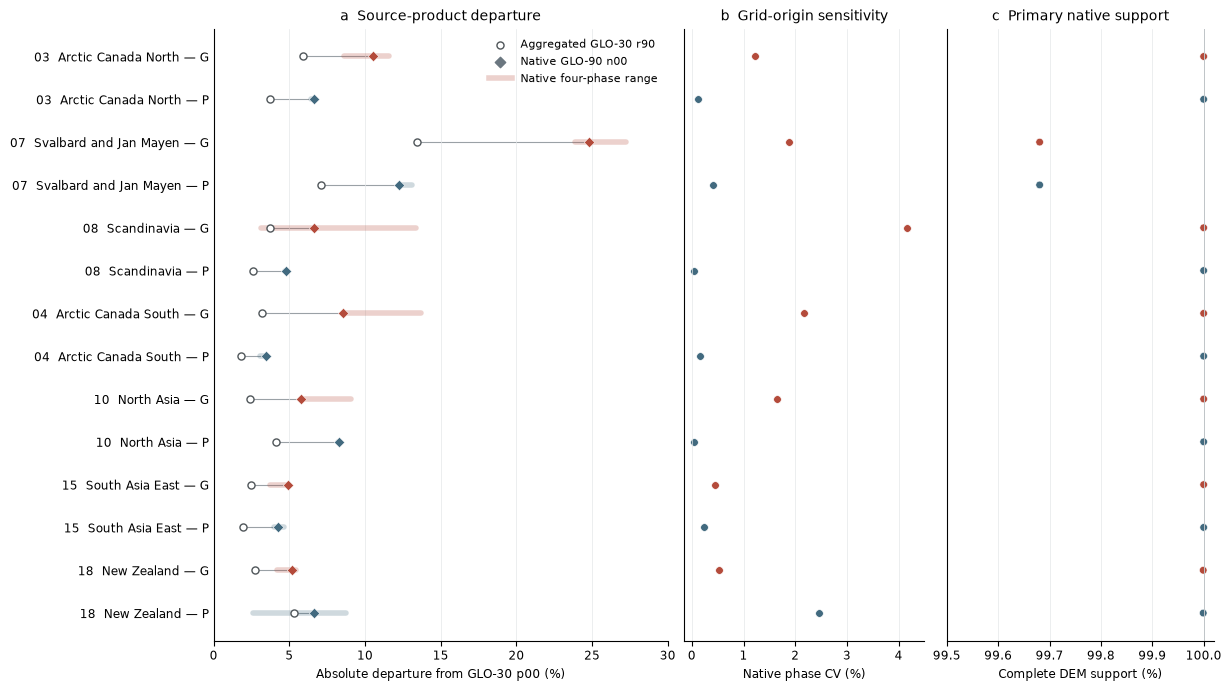

In [2]:
colors = {'glacier_proximity':'#b44b3b','permafrost':'#426a7f'}
plt.rcParams.update({'font.size':8.5,'axes.spines.top':False,'axes.spines.right':False})
fig, axes = plt.subplots(1,3,figsize=(12.2,6.8),sharey=True,gridspec_kw={'width_ratios':[1.7,.9,1.0]},constrained_layout=True)
y = np.arange(len(table))[::-1]
for yi,row in zip(y,table.itertuples(index=False)):
    color = colors[row.stratum]
    axes[0].plot([row.phase_min_pct,row.phase_max_pct],[yi,yi],color=color,lw=4,alpha=.25,solid_capstyle='round')
    axes[0].plot([row.aggregated_pct,row.native_pct],[yi,yi],color='#9aa1a6',lw=.8,zorder=1)
    axes[0].scatter(row.aggregated_pct,yi,s=26,facecolor='white',edgecolor='#50565a',lw=1,zorder=2)
    axes[0].scatter(row.native_pct,yi,s=28,marker='D',color=color,edgecolor='white',lw=.35,zorder=3)
axes[0].scatter([],[],s=26,facecolor='white',edgecolor='#50565a',label='Aggregated GLO-30 r90'); axes[0].scatter([],[],s=28,marker='D',color='#6b7780',label='Native GLO-90 n00'); axes[0].plot([],[],color='#b44b3b',lw=4,alpha=.25,label='Native four-phase range')
axes[0].set(xlabel='Absolute departure from GLO-30 p00 (%)',title='a  Source-product departure',xlim=(0,30),yticks=y,yticklabels=table.label); axes[0].grid(axis='x',color='#e4e7e9',lw=.5)
axes[0].legend(frameon=False,loc='upper right',fontsize=8)
for stratum,color in colors.items():
    q = table.stratum.eq(stratum); axes[1].scatter(100*table.loc[q,'native_phase_cv'],y[q],s=30,color=color,edgecolor='white',lw=.4)
axes[1].set(xlabel='Native phase CV (%)',title='b  Grid-origin sensitivity',xlim=(-.15,4.5)); axes[1].grid(axis='x',color='#e4e7e9',lw=.5)
axes[2].scatter(100*table.primary_complete_support_fraction,y,s=30,c=table.stratum.map(colors),edgecolor='white',lw=.4)
axes[2].set(xlabel='Complete DEM support (%)',title='c  Primary native support',xlim=(99.5,100.02)); axes[2].axvline(100,color='#bfc4c7',lw=.7)
axes[2].grid(axis='x',color='#e4e7e9',lw=.5)
for ax in axes: ax.tick_params(axis='y',length=0)
fig.savefig(root/'figures/native_glo90_transfer.png',dpi=300,bbox_inches='tight')
fig.savefig(root/'figures/native_glo90_transfer.pdf',bbox_inches='tight')
plt.show()

Native `n00` departure is larger than strict GLO-30 aggregation in all 14 exposed comparisons: 3.45–24.81% versus 1.81–13.43%, with medians 6.65% and 3.44%. Across native phases, departures span 2.57–27.26% and the maximum phase coefficient of variation is 4.17%. These results show that source-product processing matters in this development set; they do not validate a threshold, estimate a global total, or identify hazardous slopes.